# CS490/590 Capstone Project: Predicting Premier League Outcomes 
**Author:** Prajwal DC

### README: Critical Instructions for Execution
**1. Extract the Archive:** If you downloaded this submission as a `.zip` file, you MUST extract/unzip the entire folder first. The code will fail if run directly from inside a compressed preview window.
**2. Working Directory:** Ensure the following three CSV files are located in the exact same unzipped directory as this `.ipynb` file:
   * `Cleaned_Master_Dataset.csv` (Historical match data with EA FC 26 proxy ratings) This is a combination of dataset from this season           premier league data which can be found on (https://www.football-data.co.uk/englandm.php) and historical data from kaggle (https://www.kaggle.com/datasets/marcohuiii/english-premier-league-epl-match-data-2000-2025) where was later filtered down to premier league data from 2022/2024.
   * `Arsenal-players.csv` (Current roster data) Dataset Link: (https://www.ea.com/games/ea-sports-fc/ratings?gender=0&team=1&team=10)
   * `ManchesterCity-Players.csv` (Current roster data) Dataset Link: (https://www.ea.com/games/ea-sports-fc/ratings?gender=0&team=1&team=10)

**Objective:** This project utilizes EA FC 26 player ratings to solve the "Cold Start" problem for newly promoted or altered squads. It trains a Random Forest classifier on historical data and utilizes a custom Key Player Index (KPI) to simulate squad depth sensitivity for the 2025/2026 title race.

Data Loading and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore') # Keeps final output clean for the report

# Load the Master Dataset
df = pd.read_csv('Cleaned_Master_Dataset.csv')

# Define Features
features = ['home_ea_attack', 'home_ea_midfield', 'home_ea_defense', 'home_ea_overall', 'away_ea_attack', 'away_ea_midfield', 'away_ea_defense', 'away_ea_overall']

# Clean Missing Values
df_clean = df.dropna(subset=features + ['home_win_flag']).copy()

print("Environment setup complete. Master dataset loaded successfully.")

Environment setup complete. Master dataset loaded successfully.


Exploratory Data Analysis (EDA)
Validating the statistical relationship between the EA FC proxy ratings and real-world match outcomes.

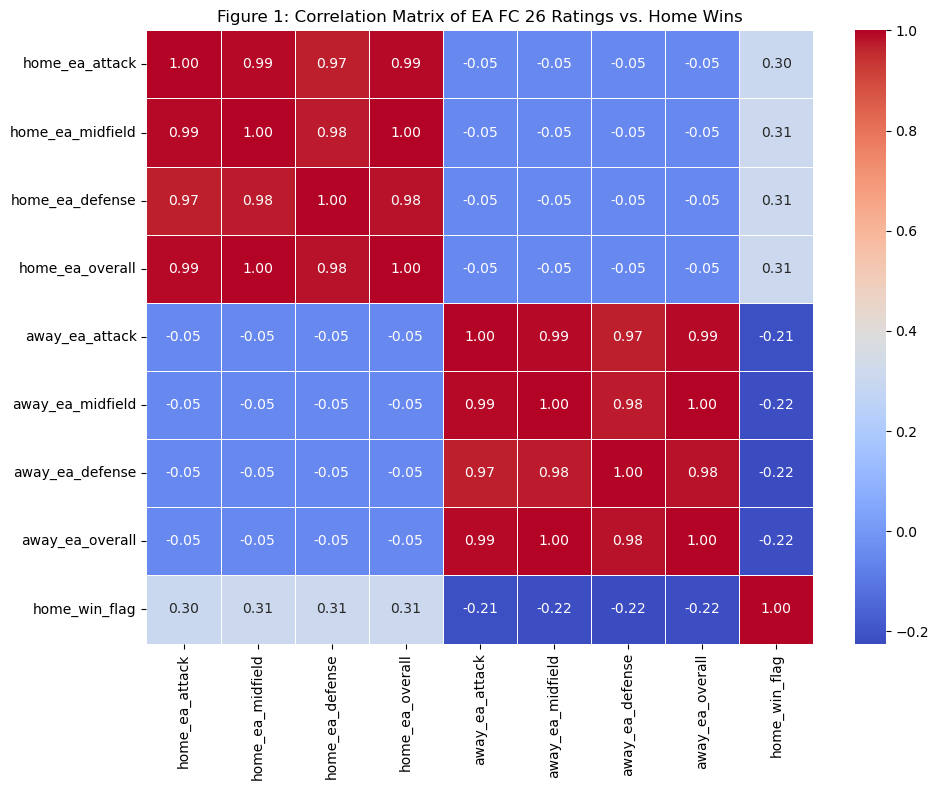

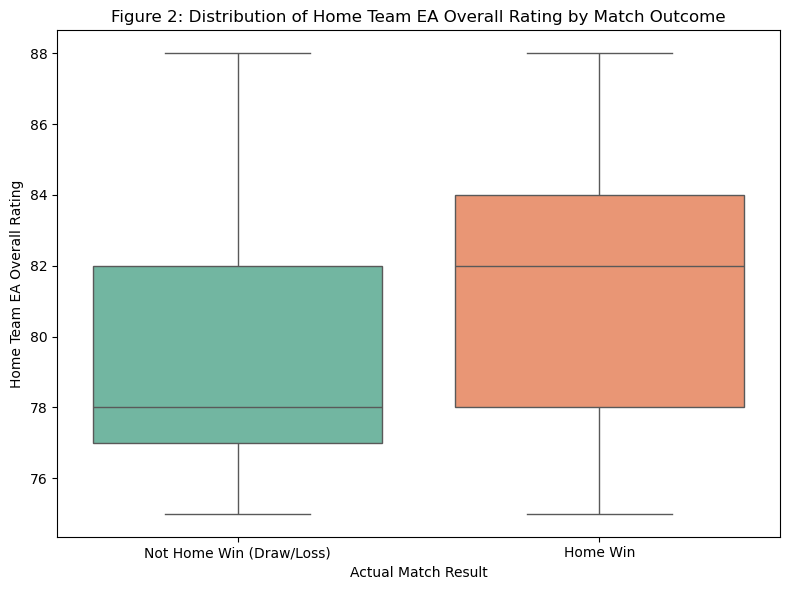

In [3]:
# --- FIGURE 1: CORRELATION HEATMAP ---
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[features + ['home_win_flag']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Figure 1: Correlation Matrix of EA FC 26 Ratings vs. Home Wins')
plt.tight_layout()
plt.savefig('EDA_Correlation_Heatmap.png', dpi=300)
plt.show()

# --- FIGURE 2: BOXPLOT OF RATINGS VS OUTCOME ---
plt.figure(figsize=(8, 6))
df_clean['Outcome'] = df_clean['home_win_flag'].map({1: 'Home Win', 0: 'Not Home Win (Draw/Loss)'})

# Plotting Home Overall Rating distribution
sns.boxplot(x='Outcome', y='home_ea_overall', data=df_clean, hue='Outcome', palette='Set2', legend=False)
plt.title('Figure 2: Distribution of Home Team EA Overall Rating by Match Outcome')
plt.xlabel('Actual Match Result')
plt.ylabel('Home Team EA Overall Rating')
plt.tight_layout()
plt.savefig('EDA_Boxplot_Outcome.png', dpi=300)
plt.show()

Model Training & Evaluation
Comparing a baseline Logistic Regression model against an advanced Random Forest ensemble.

In [ ]:
# Split the Data
X = df_clean[features]
y = df_clean['home_win_flag']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline Model: Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
log_acc = accuracy_score(y_test, y_pred_log)

# Advanced Model: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

# Print Results
print(f"--- Baseline Logistic Regression Accuracy: {log_acc:.4f} ---")
print(f"--- Advanced Random Forest Accuracy:       {rf_acc:.4f} ---\n")
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

--- Baseline Logistic Regression Accuracy: 0.7315 ---
--- Advanced Random Forest Accuracy:       0.7349 ---

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.79      0.77       166
           1       0.72      0.67      0.69       132

    accuracy                           0.73       298
   macro avg       0.73      0.73      0.73       298
weighted avg       0.73      0.73      0.73       298



Feature Importance
Visualizing which EA proxy ratings the Random Forest model relied on most heavily to predict outcomes.

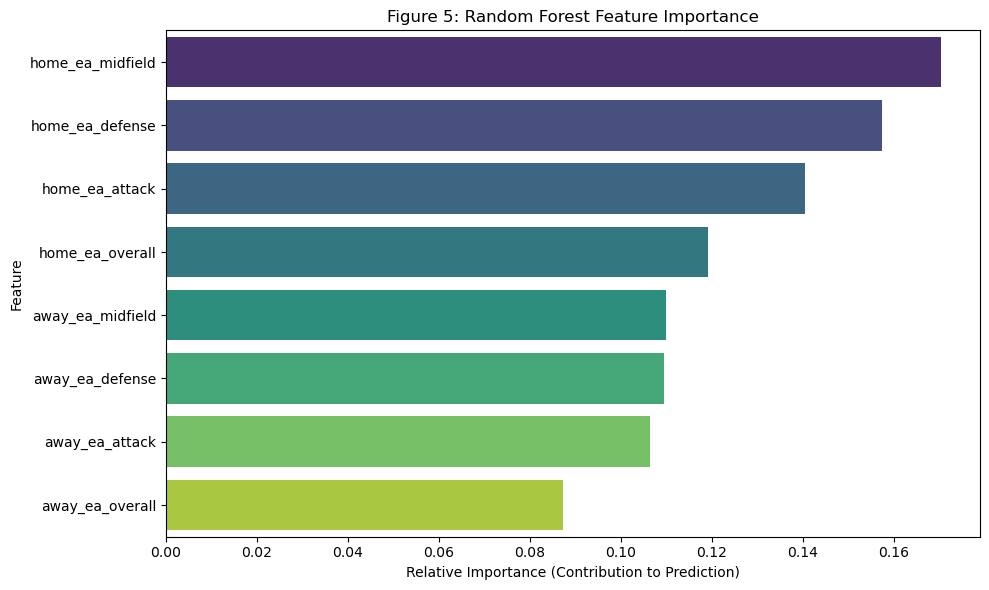

In [9]:
# Extract and sort feature importances
fi_df = pd.DataFrame({'Feature': features, 'Importance': rf_model.feature_importances_})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, hue='Feature', palette='viridis', legend=False)
plt.title('Figure 5: Random Forest Feature Importance')
plt.xlabel('Relative Importance (Contribution to Prediction)')
plt.tight_layout()
plt.savefig('Random_Forest_Importance.png', dpi=300)
plt.show()

Visualizing the Random Forest's performance using a Confusion Matrix and a Receiver Operating Characteristic (ROC) curve.

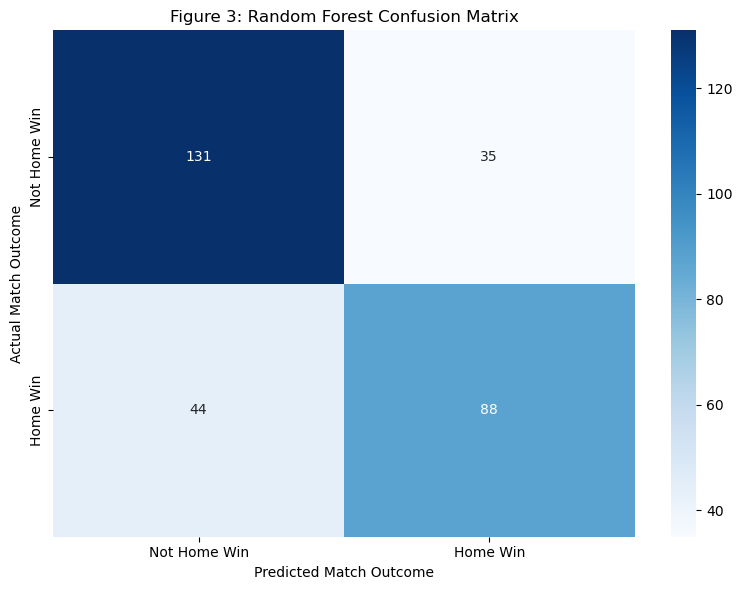

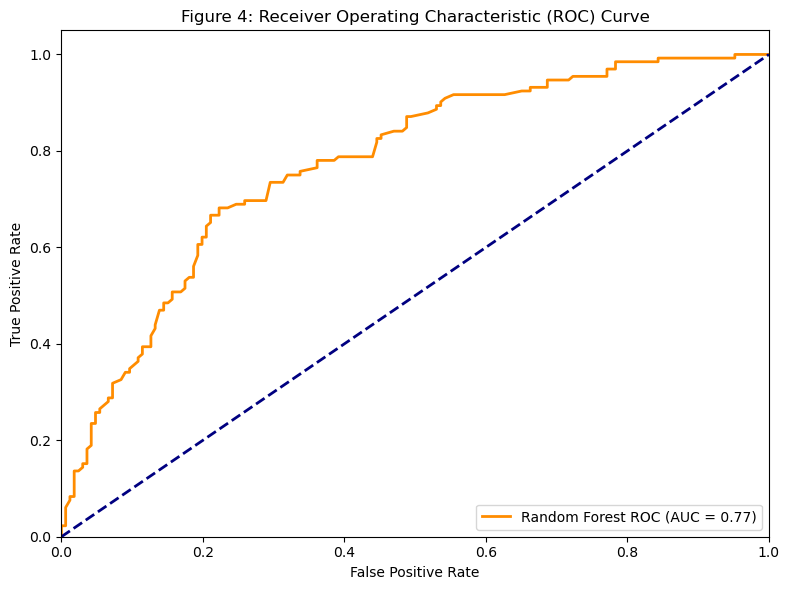

In [10]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# FIGURE 4: CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Home Win', 'Home Win'], yticklabels=['Not Home Win', 'Home Win'])

plt.title('Figure 3: Random Forest Confusion Matrix')
plt.xlabel('Predicted Match Outcome')
plt.ylabel('Actual Match Outcome')
plt.tight_layout()

# Save and render
plt.savefig('RF_Confusion_Matrix.png', dpi=300)
plt.show()

# FIGURE 5: ROC CURVE

y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Baseline random guess
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 4: Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.tight_layout()

# Save and render
plt.savefig('RF_ROC_Curve.png', dpi=300)
plt.show()

CS590 Additional Analysis (Key Player Index Simulation)
Applying a custom KPI penalty to quantify the impact of squad depletion on the 2025/2026 title race between Manchester City and Arsenal.

In [ ]:
# Helper function to clean text from stats (e.g., keeper stat: '85 (HAN)' -> 85)
def clean_stat(val):
    if pd.isna(val): return 0
    digits = re.search(r'\d+', str(val))
    return int(digits.group()) if digits else 0

# Load and Clean Roster Data
df_ars = pd.read_csv('Arsenal-players.csv')
df_mci = pd.read_csv('ManchesterCity-Players.csv')

for col in ['OVR Rating', 'Shooting', 'Passing', 'Defending']:
    df_ars[col] = df_ars[col].apply(clean_stat)
    df_mci[col] = df_mci[col].apply(clean_stat)

# Calculate True Top 11 Baselines
baseline_ratings = {
    'Arsenal': {
        'Attack': df_ars.nlargest(11, 'Shooting')['Shooting'].mean(),
        'Midfield': df_ars.nlargest(11, 'Passing')['Passing'].mean(),
        'Defense': df_ars.nlargest(11, 'Defending')['Defending'].mean(),
        'Overall': df_ars.nlargest(11, 'OVR Rating')['OVR Rating'].mean()
    },
    'Manchester City': {
        'Attack': df_mci.nlargest(11, 'Shooting')['Shooting'].mean(),
        'Midfield': df_mci.nlargest(11, 'Passing')['Passing'].mean(),
        'Defense': df_mci.nlargest(11, 'Defending')['Defending'].mean(),
        'Overall': df_mci.nlargest(11, 'OVR Rating')['OVR Rating'].mean()
    }
}

# KPI Penalty Logic
def calculate_kpi_penalty(team, injured_players, rating_category='Overall'):
    roster = df_ars if team == 'Arsenal' else df_mci
    stat_col = 'OVR Rating'
    if rating_category == 'Attack': stat_col = 'Shooting'
    elif rating_category == 'Defense': stat_col = 'Defending'
    elif rating_category == 'Midfield': stat_col = 'Passing'
    
    top_11_base = roster.nlargest(11, stat_col)[stat_col].mean()
    active_roster = roster[~roster['Player Name'].isin(injured_players)]
    top_11_adj = active_roster.nlargest(11, stat_col)[stat_col].mean()
    return top_11_base - top_11_adj

# The Predictor
def simulate_head_to_head(home_team, away_team, home_missing=[], away_missing=[]):
    h_base = baseline_ratings[home_team]
    a_base = baseline_ratings[away_team]
    
    h_atk = h_base['Attack'] - calculate_kpi_penalty(home_team, home_missing, 'Attack')
    h_mid = h_base['Midfield'] - calculate_kpi_penalty(home_team, home_missing, 'Midfield')
    h_def = h_base['Defense'] - calculate_kpi_penalty(home_team, home_missing, 'Defense')
    h_ovr = h_base['Overall'] - calculate_kpi_penalty(home_team, home_missing, 'Overall')
    
    a_atk = a_base['Attack'] - calculate_kpi_penalty(away_team, away_missing, 'Attack')
    a_mid = a_base['Midfield'] - calculate_kpi_penalty(away_team, away_missing, 'Midfield')
    a_def = a_base['Defense'] - calculate_kpi_penalty(away_team, away_missing, 'Defense')
    a_ovr = a_base['Overall'] - calculate_kpi_penalty(away_team, away_missing, 'Overall')
    
    match_features = pd.DataFrame([{
        'home_ea_attack': h_atk, 'home_ea_midfield': h_mid, 'home_ea_defense': h_def, 'home_ea_overall': h_ovr,
        'away_ea_attack': a_atk, 'away_ea_midfield': a_mid, 'away_ea_defense': a_def, 'away_ea_overall': a_ovr
    }])
    
    win_prob = rf_model.predict_proba(match_features)[0]
    
    print(f"MATCHUP: {home_team} (Home) vs {away_team} (Away)")
    if home_missing: print(f"{home_team} Missing: {', '.join(home_missing)}")
    if away_missing: print(f"{away_team} Missing: {', '.join(away_missing)}")
    print(f"{home_team} Win Probability: {win_prob[1]*100:.1f}%")
    print(f"Draw/{away_team} Win Probability: {win_prob[0]*100:.1f}%")
    print("-" * 45)

Executing Scenarios

In [7]:
print("--- SCENARIO 1: FULL STRENGTH BASELINE ---")
simulate_head_to_head('Manchester City', 'Arsenal')

print("\n--- SCENARIO 2: ARSENAL LOSES KEY PLAYERS ---")
simulate_head_to_head('Manchester City', 'Arsenal', away_missing=['Bukayo Saka', 'Martin Ødegaard'])

print("\n--- SCENARIO 3: MAN CITY SQUAD DEPLETION ---")
simulate_head_to_head('Manchester City', 'Arsenal', home_missing=['Erling Haaland', 'Rodri'])

--- SCENARIO 1: FULL STRENGTH BASELINE ---
MATCHUP: Manchester City (Home) vs Arsenal (Away)
Manchester City Win Probability: 42.9%
Draw/Arsenal Win Probability: 57.1%
---------------------------------------------

--- SCENARIO 2: ARSENAL LOSES KEY PLAYERS ---
MATCHUP: Manchester City (Home) vs Arsenal (Away)
Arsenal Missing: Bukayo Saka, Martin Ødegaard
Manchester City Win Probability: 47.2%
Draw/Arsenal Win Probability: 52.8%
---------------------------------------------

--- SCENARIO 3: MAN CITY SQUAD DEPLETION ---
MATCHUP: Manchester City (Home) vs Arsenal (Away)
Manchester City Missing: Erling Haaland, Rodri
Manchester City Win Probability: 33.2%
Draw/Arsenal Win Probability: 66.8%
---------------------------------------------
